In [15]:
# =============================================================================
# TOPIC MODELING LDA - JURNAL PINTER
# Metode: LDA dengan TF-IDF, FastText, dan Kombinasi
# Oleh: Mahasiswa Skripsi
# =============================================================================
# INSTALASI LIBRARY (jalankan di terminal/cell terpisah):
# pip install gensim scikit-learn nltk PySastrawi matplotlib pyLDAvis pandas numpy
# =============================================================================

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0: IMPORT SEMUA LIBRARY
# ─────────────────────────────────────────────────────────────────────────────

import os
import re
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# NLP & Preprocessing
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Representasi Teks
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import issparse

# Gensim - LDA & FastText
import gensim
from gensim import corpora
from gensim.models import LdaModel, FastText, CoherenceModel
from gensim.matutils import Sparse2Corpus

# pyLDAvis untuk visualisasi interaktif
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Suppress warnings agar output bersih
warnings.filterwarnings("ignore")

# Download resource NLTK yang dibutuhkan
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: KONFIGURASI GLOBAL
# ─────────────────────────────────────────────────────────────────────────────

# ==== GANTI PATH INI SESUAI LOKASI FOLDER FILE .txt ANDA ====
FOLDER_PATH = "/Users/davinarazi/Documents/SKRISPI SAYA/Data/Jurnal 1/vol 1/txt"
# Contoh: "C:/Users/Anda/Desktop/artikel"
# ============================================================

NUM_TOPICS = 3                       # Jumlah topik (RPL, MM, TKJ)
TOPIC_LABELS = {0: "RPL", 1: "MM", 2: "TKJ"}
FASTTEXT_VECTOR_SIZE = 300           # Ukuran vektor FastText
FASTTEXT_WINDOW = 5                  # Window size FastText
FASTTEXT_MIN_COUNT = 1               # Minimum frekuensi kata
LDA_PASSES = 50                      # Jumlah iterasi training LDA
LDA_RANDOM_STATE = 42                # Seed untuk reproducibility

print(f"✅ Konfigurasi global:")
print(f"   Folder data : {FOLDER_PATH}")
print(f"   Jumlah topik: {NUM_TOPICS}")
print(f"   Vector size : {FASTTEXT_VECTOR_SIZE}")

✅ Konfigurasi global:
   Folder data : /Users/davinarazi/Documents/SKRISPI SAYA/Data/Jurnal 1/vol 1/txt
   Jumlah topik: 3
   Vector size : 300


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: MEMBACA DATA (10 FILE .txt)
# ─────────────────────────────────────────────────────────────────────────────

def load_documents(folder_path):
    """
    Membaca semua file .txt dari folder yang ditentukan.

    Parameters:
        folder_path (str): Path ke folder berisi file .txt

    Returns:
        tuple: (list of raw texts, list of filenames)
    """
    # Cari semua file .txt di folder
    txt_files = sorted(glob.glob(os.path.join(folder_path, "*.txt")))

    if not txt_files:
        raise FileNotFoundError(
            f"Tidak ada file .txt ditemukan di folder: {folder_path}\n"
            f"Pastikan path sudah benar dan folder berisi file .txt"
        )

    documents = []
    filenames = []

    for filepath in txt_files:
        filename = os.path.basename(filepath)
        try:
            # Coba baca dengan encoding UTF-8 terlebih dahulu
            with open(filepath, "r", encoding="utf-8") as f:
                text = f.read()
        except UnicodeDecodeError:
            # Fallback ke latin-1 jika UTF-8 gagal
            with open(filepath, "r", encoding="latin-1") as f:
                text = f.read()

        documents.append(text)
        filenames.append(filename)
        print(f"   📄 Loaded: {filename} ({len(text)} karakter)")

    print(f"\n✅ Total dokumen dimuat: {len(documents)} file")
    return documents, filenames


print("\n📂 Membaca dokumen...")
raw_documents, filenames = load_documents(FOLDER_PATH)


📂 Membaca dokumen...
   📄 Loaded: Juannita.txt (21378 karakter)
   📄 Loaded: Rima.txt (15314 karakter)
   📄 Loaded: affni.txt (9831 karakter)
   📄 Loaded: bachren.txt (23256 karakter)
   📄 Loaded: ficky.txt (19215 karakter)
   📄 Loaded: hamidillah.txt (16063 karakter)
   📄 Loaded: lipur.txt (17150 karakter)
   📄 Loaded: minal abral.txt (17311 karakter)
   📄 Loaded: nur indah.txt (17991 karakter)
   📄 Loaded: regina.txt (14152 karakter)

✅ Total dokumen dimuat: 10 file


In [19]:
# ─────────────────────────────────────────────────────
# SECTION 3: PREPROCESSING BAHASA INDONESIA
# ─────────────────────────────────────────────────────────────────────────────

# --- Inisialisasi tools Sastrawi ---
from nltk.corpus import stopwords

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

stop_words1 = set(stopwords.words('indonesian'))
stopword_factory = StopWordRemoverFactory()
stopword_remover = stopword_factory.create_stop_word_remover()
stop_words = set(stopword_factory.get_stop_words())

# Tambahkan custom stopwords yang umum di artikel ilmiah
CUSTOM_STOPWORDS = {
    "penelitian", "jurnal", "pinter", "artikel", "abstrak", "abstract",
    "kata", "kunci", "keywords", "pendahuluan", "metode", "hasil",
    "kesimpulan", "pembahasan", "daftar", "pustaka", "gambar", "tabel",
    "doi", "issn", "vol", "no", "hal", "hlm", "pp", "et", "al",
    "dalam", "yang", "dengan", "pada", "untuk", "dari", "ini", "itu",
    "adalah", "atau", "dan", "juga", "dapat", "oleh", "sebagai",
    "sistem", "data", "menggunakan", "analisis", "proses", "hasil"
}
stop_words2= stop_words.union(CUSTOM_STOPWORDS)
stop_words3= stop_words2.union(stop_words1)
stop_words3 = set([stemmer.stem(w.strip()) for w in stop_words3])

,
def case_folding(text):
    """
    Langkah 1: Case Folding
    - Ubah semua huruf menjadi lowercase
    - Hapus karakter non-alfabet (angka, tanda baca, dll)
    - Hapus spasi berlebih
    """
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)    # Hanya simpan huruf & spasi
    text = re.sub(r'\s+', ' ', text).strip()   # Normalisasi spasi
    return text


def tokenize_text(text):
    """
    Langkah 2: Tokenisasi
    - Pecah teks menjadi daftar token (kata)
    - Filter kata yang terlalu pendek (< 3 karakter)
    """
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if len(t) >= 3]  # Minimal 3 karakter
    return tokens


def remove_stopwords(tokens):
    """
    Langkah 3: Stopword Removal
    - Hapus kata-kata umum yang tidak memberi makna
    - Menggunakan daftar stopwords Sastrawi + custom stopwords
    """
    filtered = [t for t in tokens if t not in stop_words3]
    return filtered


def stem_tokens(tokens):
    """
    Langkah 4: Stemming dengan Sastrawi
    - Ubah kata ke bentuk dasar (root word)
    - Contoh: "pembelajaran" → "ajar", "menggunakan" → "guna"
    """
    stemmed = [stemmer.stem(token) for token in tokens]
    stemmed = [t for t in stemmed if len(t) >= 3]
    return stemmed


def preprocess_document(text):
    """
    Pipeline lengkap preprocessing satu dokumen:
    case folding → tokenisasi → stopword removal → stemming

    Returns:
        list of str: Daftar token yang sudah diproses
    """
    text = case_folding(text)
    tokens = tokenize_text(text)
    tokens = stem_tokens(tokens)
    tokens = remove_stopwords(tokens)
    return tokens


def preprocess_all_documents(raw_docs):
    """
    Preprocessing semua dokumen sekaligus.

    Returns:
        list of list of str: Daftar token per dokumen
    """
    processed = []
    for i, doc in enumerate(raw_docs):
        tokens = preprocess_document(doc)
        processed.append(tokens)
        print(f"   ✂️  Dokumen {i+1}: {len(tokens)} token setelah preprocessing")
    return processed


print("\n🔧 Memulai preprocessing...")
processed_docs = preprocess_all_documents(raw_documents)

# Cek hasil preprocessing
print(f"\n✅ Preprocessing selesai!")
print(f"   Contoh 10 token pertama dari dokumen 1: {processed_docs[0][:10]}")


🔧 Memulai preprocessing...
   ✂️  Dokumen 1: 1439 token setelah preprocessing
   ✂️  Dokumen 2: 1078 token setelah preprocessing
   ✂️  Dokumen 3: 705 token setelah preprocessing
   ✂️  Dokumen 4: 1513 token setelah preprocessing
   ✂️  Dokumen 5: 1303 token setelah preprocessing
   ✂️  Dokumen 6: 996 token setelah preprocessing
   ✂️  Dokumen 7: 1231 token setelah preprocessing
   ✂️  Dokumen 8: 1212 token setelah preprocessing
   ✂️  Dokumen 9: 1030 token setelah preprocessing
   ✂️  Dokumen 10: 1006 token setelah preprocessing

✅ Preprocessing selesai!
   Contoh 10 token pertama dari dokumen 1: ['kembang', 'media', 'ajar', 'cerna', 'manusia', 'kelas', 'smp', 'fitur', 'augmented', 'reality']


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: REPRESENTASI TEKS
# ─────────────────────────────────────────────────────────────────────────────

# ============================
# 4A. TF-IDF (sklearn)
# ============================

def build_tfidf(processed_docs):
    """
    Membangun representasi TF-IDF dari dokumen yang sudah dipreprocessing.

    TF-IDF mengukur pentingnya kata dalam dokumen relatif terhadap
    seluruh korpus. Kata yang sering muncul di dokumen tapi jarang
    di korpus mendapat bobot tinggi.

    Returns:
        tfidf_matrix  : sparse matrix (n_docs x n_terms)
        vectorizer    : TfidfVectorizer yang sudah difit
        feature_names : nama-nama fitur (kata)
    """
    # Gabungkan token per dokumen menjadi string untuk sklearn
    corpus_strings = [" ".join(tokens) for tokens in processed_docs]

    vectorizer = TfidfVectorizer(
        max_features=5000,      # Batasi vocabulary agar tidak terlalu besar
        min_df=1,               # Kata harus muncul minimal di 1 dokumen
        max_df=0.95,            # Abaikan kata yang muncul di >95% dokumen
        ngram_range=(1, 2),     # Gunakan unigram dan bigram
    )

    tfidf_matrix = vectorizer.fit_transform(corpus_strings)
    feature_names = vectorizer.get_feature_names_out()

    print(f"   TF-IDF shape: {tfidf_matrix.shape} (dokumen x fitur)")
    print(f"   Vocabulary size: {len(feature_names)}")

    return tfidf_matrix, vectorizer, feature_names


print("\n📊 Membangun representasi TF-IDF...")
tfidf_matrix, tfidf_vectorizer, tfidf_features = build_tfidf(processed_docs)
print("✅ TF-IDF berhasil dibangun!")


# ============================
# 4B. FastText (gensim)
# ============================

def build_fasttext(processed_docs, vector_size=300, window=5, min_count=1):
    """
    Melatih model FastText dari corpus sendiri.

    FastText adalah word embedding yang mempertimbangkan subword information,
    sehingga bisa menangani kata OOV (Out Of Vocabulary) dan kata morphologi
    Bahasa Indonesia dengan baik.

    Parameters:
        processed_docs: list of list of str (token per dokumen)
        vector_size   : dimensi embedding (default 300)
        window        : context window size
        min_count     : minimum frekuensi kata

    Returns:
        ft_model: model FastText yang sudah ditraining
    """
    print(f"   Training FastText (vector_size={vector_size}, window={window})...")

    ft_model = FastText(
        sentences=processed_docs,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=4,               # Gunakan 4 core CPU
        epochs=100,              # Epochs training
        sg=1,                    # Skip-gram (lebih baik untuk small corpus)
        seed=LDA_RANDOM_STATE,
    )

    vocab_size = len(ft_model.wv.key_to_index)
    print(f"   FastText vocabulary size: {vocab_size} kata")
    print(f"   Contoh embedding 'sistem': {ft_model.wv['sistem'][:5]}...")

    return ft_model


print("\n🧠 Training FastText embedding...")
ft_model = build_fasttext(processed_docs, vector_size=FASTTEXT_VECTOR_SIZE)
print("✅ FastText berhasil ditraining!")


def get_doc_vector_fasttext(tokens, ft_model):
    """
    Membuat document vector dari rata-rata embedding kata (mean pooling).

    Setiap dokumen direpresentasikan sebagai rata-rata vektor
    semua kata yang ada di dalamnya.

    Returns:
        np.array: vektor dokumen berukuran (vector_size,)
    """
    vectors = []
    for token in tokens:
        try:
            vec = ft_model.wv[token]
            vectors.append(vec)
        except KeyError:
            continue

    if vectors:
        return np.mean(vectors, axis=0)
    else:
        # Jika tidak ada kata yang dikenal, return zero vector
        return np.zeros(ft_model.vector_size)


# Buat document vectors untuk semua dokumen
doc_vectors_ft = np.array([
    get_doc_vector_fasttext(tokens, ft_model)
    for tokens in processed_docs
])
print(f"\n✅ Document vectors FastText shape: {doc_vectors_ft.shape}")


📊 Membangun representasi TF-IDF...
   TF-IDF shape: (10, 5000) (dokumen x fitur)
   Vocabulary size: 5000
✅ TF-IDF berhasil dibangun!

🧠 Training FastText embedding...
   Training FastText (vector_size=300, window=5)...
   FastText vocabulary size: 1732 kata
   Contoh embedding 'sistem': [-0.50954443 -0.03257566  0.34466276  0.09924706  0.40176234]...
✅ FastText berhasil ditraining!

✅ Document vectors FastText shape: (10, 300)


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: PERSIAPAN CORPUS UNTUK GENSIM LDA
# ─────────────────────────────────────────────────────────────────────────────

def build_gensim_corpus(processed_docs):
    """
    Membangun dictionary dan corpus format gensim (Bag of Words).
    Ini digunakan sebagai basis untuk semua skenario LDA.

    Returns:
        dictionary: gensim Dictionary
        corpus_bow : list of (word_id, count) per dokumen
    """
    # Buat dictionary dari corpus
    dictionary = corpora.Dictionary(processed_docs)

    # Filter extremes: hapus kata yang terlalu jarang atau terlalu umum
    dictionary.filter_extremes(
        no_below=2,     # Kata harus muncul di minimal 1 dokumen
        no_above=0.8,   # Tidak ada batas atas (karena corpus kecil)
        keep_n=5000     # Simpan maksimal 5000 kata
    )

    # Buat representasi Bag of Words
    corpus_bow = [dictionary.doc2bow(doc) for doc in processed_docs]

    print(f"   Dictionary size: {len(dictionary)} kata unik")
    print(f"   Corpus size: {len(corpus_bow)} dokumen")

    return dictionary, corpus_bow


print("\n📚 Membangun gensim dictionary & corpus...")
dictionary, corpus_bow = build_gensim_corpus(processed_docs)
print("✅ Corpus gensim berhasil dibangun!")


def tfidf_to_gensim_corpus(tfidf_matrix, feature_names, dictionary):
    """
    Konversi TF-IDF matrix (sklearn sparse) ke format corpus gensim.

    Proses: Mapping indeks sklearn → gensim dictionary ID,
    lalu format sebagai list of (word_id, tfidf_weight).

    Returns:
        corpus_tfidf_gensim: list of (word_id, weight) per dokumen
    """
    # Buat mapping: kata → ID di gensim dictionary
    word2id = {v: k for k, v in dictionary.items()}

    corpus_tfidf_gensim = []
    tfidf_dense = tfidf_matrix.toarray()  # Convert ke dense array

    for doc_vec in tfidf_dense:
        doc_bow = []
        for feat_idx, weight in enumerate(doc_vec):
            if weight > 0:
                word = feature_names[feat_idx]
                # Ambil hanya kata yang ada di gensim dictionary
                if word in word2id:
                    doc_bow.append((word2id[word], float(weight)))
        # Sort berdasarkan word_id (required by gensim)
        doc_bow.sort(key=lambda x: x[0])
        corpus_tfidf_gensim.append(doc_bow)

    return corpus_tfidf_gensim


def fasttext_to_gensim_corpus(doc_vectors, dictionary, processed_docs, ft_model):
    """
    Konversi FastText document vectors ke format corpus gensim.

    Strategi:
    1. Untuk setiap dokumen, ambil token yang ada
    2. Gunakan cosine similarity FastText sebagai bobot kata
    3. Format sebagai list of (word_id, weight)

    Returns:
        corpus_ft_gensim: list of (word_id, weight) per dokumen
    """
    word2id = {v: k for k, v in dictionary.items()}

    corpus_ft_gensim = []

    for i, (tokens, doc_vec) in enumerate(zip(processed_docs, doc_vectors)):
        doc_bow = []
        seen_ids = set()

        for token in tokens:
            # Cek apakah token ada di gensim dictionary
            if token in word2id:
                word_id = word2id[token]
                if word_id not in seen_ids:
                    try:
                        # Hitung cosine similarity antara kata & dokumen
                        word_vec = ft_model.wv[token]
                        doc_norm = np.linalg.norm(doc_vec)
                        word_norm = np.linalg.norm(word_vec)

                        if doc_norm > 0 and word_norm > 0:
                            similarity = np.dot(doc_vec, word_vec) / (doc_norm * word_norm)
                            # Normalize ke [0, 1]
                            weight = max(0, float(similarity))
                        else:
                            weight = 0.0

                        doc_bow.append((word_id, weight))
                        seen_ids.add(word_id)

                    except KeyError:
                        # Jika kata tidak ada di FastText, gunakan bobot kecil
                        doc_bow.append((word_id, 0.01))
                        seen_ids.add(word_id)

        # Sort berdasarkan word_id
        doc_bow.sort(key=lambda x: x[0])

        # Pastikan ada minimal beberapa kata dengan bobot positif
        if not doc_bow:
            # Fallback: gunakan BoW biasa
            doc_bow = dictionary.doc2bow(tokens)

        corpus_ft_gensim.append(doc_bow)

    return corpus_ft_gensim


def combined_tfidf_fasttext_corpus(tfidf_matrix, feature_names, dictionary,
                                    processed_docs, ft_model, alpha=0.7):
    """
    Menggabungkan TF-IDF dan FastText sebagai pembobot.

    Formula: weight = alpha * tfidf_weight + (1-alpha) * fasttext_similarity

    Parameter alpha mengontrol seberapa besar kontribusi TF-IDF vs FastText.
    alpha=0.7 berarti 70% TF-IDF + 30% FastText.

    Returns:
        corpus_combined: list of (word_id, combined_weight) per dokumen
    """
    word2id = {v: k for k, v in dictionary.items()}
    tfidf_dense = tfidf_matrix.toarray()

    # Dapatkan document vectors FastText
    doc_vectors = np.array([
        get_doc_vector_fasttext(tokens, ft_model)
        for tokens in processed_docs
    ])

    corpus_combined = []

    for i, (tokens, doc_vec) in enumerate(zip(processed_docs, doc_vectors)):
        doc_bow_dict = {}

        # === Komponen 1: TF-IDF ===
        for feat_idx, tfidf_weight in enumerate(tfidf_dense[i]):
            if tfidf_weight > 0:
                word = feature_names[feat_idx]
                if word in word2id:
                    word_id = word2id[word]
                    doc_bow_dict[word_id] = doc_bow_dict.get(word_id, 0) + alpha * tfidf_weight

        # === Komponen 2: FastText Similarity ===
        doc_norm = np.linalg.norm(doc_vec)

        for token in tokens:
            if token in word2id:
                word_id = word2id[token]
                try:
                    word_vec = ft_model.wv[token]
                    word_norm = np.linalg.norm(word_vec)

                    if doc_norm > 0 and word_norm > 0:
                        similarity = np.dot(doc_vec, word_vec) / (doc_norm * word_norm)
                        ft_weight = max(0, float(similarity))
                    else:
                        ft_weight = 0.0

                    doc_bow_dict[word_id] = doc_bow_dict.get(word_id, 0) + (1 - alpha) * ft_weight

                except KeyError:
                    pass

        # Konversi ke format gensim dan sort
        doc_bow = sorted(doc_bow_dict.items(), key=lambda x: x[0])

        if not doc_bow:
            doc_bow = dictionary.doc2bow(tokens)

        corpus_combined.append(doc_bow)

    return corpus_combined


print("\n🔄 Mengkonversi corpus ke format gensim...")

# Corpus untuk Skenario 1: TF-IDF + FastText (Kombinasi)
print("   Membangun corpus kombinasi TF-IDF + FastText (Skenario 1)...")
corpus_scenario1 = combined_tfidf_fasttext_corpus(
    tfidf_matrix, tfidf_features, dictionary, processed_docs, ft_model, alpha=0.7
)

# Corpus untuk Skenario 2: FastText saja
print("   Membangun corpus FastText (Skenario 2)...")
corpus_scenario2 = fasttext_to_gensim_corpus(
    doc_vectors_ft, dictionary, processed_docs, ft_model
)

# Corpus untuk Skenario 3: TF-IDF saja (baseline)
print("   Membangun corpus TF-IDF (Skenario 3)...")
corpus_scenario3 = tfidf_to_gensim_corpus(tfidf_matrix, tfidf_features, dictionary)

print("✅ Semua corpus berhasil dikonversi!")


📚 Membangun gensim dictionary & corpus...
   Dictionary size: 560 kata unik
   Corpus size: 10 dokumen
✅ Corpus gensim berhasil dibangun!

🔄 Mengkonversi corpus ke format gensim...
   Membangun corpus kombinasi TF-IDF + FastText (Skenario 1)...
   Membangun corpus FastText (Skenario 2)...
   Membangun corpus TF-IDF (Skenario 3)...
✅ Semua corpus berhasil dikonversi!


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: TRAINING LDA MODEL (3 SKENARIO)
# ─────────────────────────────────────────────────────────────────────────────

def train_lda_model(corpus, dictionary, num_topics, scenario_name, passes=70):
    """
    Training model LDA menggunakan gensim LdaModel.

    LDA (Latent Dirichlet Allocation) adalah model probabilistik
    yang mengasumsikan setiap dokumen merupakan campuran topik,
    dan setiap topik merupakan distribusi kata.

    Parameters:
        corpus       : corpus dalam format gensim
        dictionary   : gensim Dictionary
        num_topics   : jumlah topik
        scenario_name: nama skenario (untuk logging)
        passes       : jumlah iterasi training

    Returns:
        lda_model: model LDA yang sudah ditraining
    """
    print(f"\n   🔄 Training LDA - {scenario_name}...")

    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=passes,
        alpha='symmetric',      # Prior distribusi Dirichlet untuk dokumen-topik
        eta='symmetric',        # Prior distribusi Dirichlet untuk topik-kata
        random_state=LDA_RANDOM_STATE,
        update_every=1,
        chunksize=10,           # Ukuran chunk (sesuaikan dengan jumlah dokumen)
        per_word_topics=True,   # Aktifkan per-word topic distribution
    )

    print(f"   ✅ {scenario_name} selesai ditraining!")
    return lda_model


def compute_coherence(lda_model, corpus, dictionary, processed_docs, metric="c_v"):
    """
    Menghitung Coherence Score model LDA.

    Coherence Score mengukur seberapa bermakna topik yang dihasilkan.
    Semakin tinggi nilai c_v (range 0-1), semakin baik topiknya.

    Returns:
        float: coherence score
    """
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=processed_docs,
        dictionary=dictionary,
        coherence=metric,
        topn=10,    # Evaluasi berdasarkan 10 kata teratas per topik
    )
    return coherence_model.get_coherence()


def compute_perplexity(lda_model, corpus):
    """
    Menghitung Perplexity model LDA.

    Perplexity mengukur seberapa baik model memprediksi sampel.
    Semakin RENDAH nilai perplexity, semakin baik modelnya.

    Formula: exp(-log_perplexity)

    Returns:
        float: perplexity value
    """
    log_perplexity = lda_model.log_perplexity(corpus)
    perplexity = np.exp2(-log_perplexity)
    return perplexity


def get_topic_distribution(lda_model, corpus):
    """
    Mendapatkan distribusi topik untuk setiap dokumen.

    Returns:
        list of dict: {topic_id: probability} per dokumen
    """
    distributions = []
    for doc in corpus:
        # Inferensi distribusi topik
        topic_probs = lda_model.get_document_topics(
            doc, minimum_probability=0.0
        )
        # Konversi ke dict {topic_id: probability}
        dist = {tid: prob for tid, prob in topic_probs}
        distributions.append(dist)
    return distributions


def print_topics(lda_model, num_words=10, topic_labels=None):
    """
    Menampilkan kata-kata teratas untuk setiap topik.
    """
    topics = lda_model.show_topics(
        num_topics=lda_model.num_topics,
        num_words=num_words,
        formatted=False
    )

    for topic_id, words in topics:
        label = topic_labels.get(topic_id, f"Topik {topic_id}") if topic_labels else f"Topik {topic_id}"
        word_list = ", ".join([f"{w}({round(p,3)})" for w, p in words])
        print(f"   📌 {label}: {word_list}")


# ==========================================
# TRAINING SEMUA SKENARIO
# ==========================================

print("\n" + "="*60)
print("🚀 MULAI TRAINING LDA - 3 SKENARIO")
print("="*60)

# --- SKENARIO 1: LDA + TF-IDF + FastText ---
print("\n" + "─"*50)
print("SKENARIO 1: LDA + TF-IDF + FastText (Kombinasi)")
print("─"*50)
lda_s1 = train_lda_model(corpus_scenario1, dictionary, NUM_TOPICS, "Skenario 1")

print("\n   📌 Topik yang ditemukan:")
TOPIC_LABELS1 = {0: "RPL", 1: "MM", 2: "TKJ"} ##========= 1
print_topics(lda_s1, topic_labels=TOPIC_LABELS1)

coh_s1 = compute_coherence(lda_s1, corpus_scenario1, dictionary, processed_docs)
perp_s1 = compute_perplexity(lda_s1, corpus_scenario1)
dist_s1 = get_topic_distribution(lda_s1, corpus_scenario1)

print(f"\n   📈 Coherence Score (c_v): {coh_s1:.4f}")
print(f"   📉 Perplexity          : {perp_s1:.4f}")


# --- SKENARIO 2: LDA + FastText saja ---
print("\n" + "─"*50)
print("SKENARIO 2: LDA + FastText saja")
print("─"*50)
lda_s2 = train_lda_model(corpus_scenario2, dictionary, NUM_TOPICS, "Skenario 2")

print("\n   📌 Topik yang ditemukan:")
TOPIC_LABELS2 = {0: "RPL", 1: "MM", 2: "TKJ"} ##=========   2
print_topics(lda_s2, topic_labels=TOPIC_LABELS2)

coh_s2 = compute_coherence(lda_s2, corpus_scenario2, dictionary, processed_docs)
perp_s2 = compute_perplexity(lda_s2, corpus_scenario2)
dist_s2 = get_topic_distribution(lda_s2, corpus_scenario2)

print(f"\n   📈 Coherence Score (c_v): {coh_s2:.4f}")
print(f"   📉 Perplexity          : {perp_s2:.4f}")


# --- SKENARIO 3: LDA + TF-IDF saja (Baseline) ---
print("\n" + "─"*50)
print("SKENARIO 3: LDA + TF-IDF saja (Baseline)")
print("─"*50)
lda_s3 = train_lda_model(corpus_scenario3, dictionary, NUM_TOPICS, "Skenario 3")

print("\n   📌 Topik yang ditemukan:")
TOPIC_LABELS3 = {0: "MM", 1: "TKJ", 2: "RPL"} ##==========  3
print_topics(lda_s3, topic_labels=TOPIC_LABELS3)

coh_s3 = compute_coherence(lda_s3, corpus_scenario3, dictionary, processed_docs)
perp_s3 = compute_perplexity(lda_s3, corpus_scenario3)
dist_s3 = get_topic_distribution(lda_s3, corpus_scenario3)

print(f"\n   📈 Coherence Score (c_v): {coh_s3:.4f}")
print(f"   📉 Perplexity          : {perp_s3:.4f}")


🚀 MULAI TRAINING LDA - 3 SKENARIO

──────────────────────────────────────────────────
SKENARIO 1: LDA + TF-IDF + FastText (Kombinasi)
──────────────────────────────────────────────────

   🔄 Training LDA - Skenario 1...
   ✅ Skenario 1 selesai ditraining!

   📌 Topik yang ditemukan:
   📌 RPL: dokumen(0.03799999877810478), mahasiswa(0.017999999225139618), learning(0.017999999225139618), algoritma(0.017000000923871994), uji(0.017000000923871994), nilai(0.014999999664723873), teknik(0.014000000432133675), dosen(0.014000000432133675), kuliah(0.013000000268220901), hadir(0.012000000104308128)
   📌 MM: ajar(0.07900000363588333), siswa(0.0430000014603138), media(0.02199999988079071), kelas(0.01899999938905239), materi(0.017000000923871994), model(0.014999999664723873), multimedia(0.014999999664723873), manusia(0.014000000432133675), ranah(0.014000000432133675), faktor(0.014000000432133675)
   📌 TKJ: jaring(0.05999999865889549), server(0.029999999329447746), layan(0.028999999165534973), netwo

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: DISTRIBUSI TOPIK PER DOKUMEN
# ─────────────────────────────────────────────────────────────────────────────

def print_topic_distribution_table(distributions, filenames, topic_labels, scenario_name):
    """
    Menampilkan distribusi topik setiap dokumen dalam format tabel.
    """
    print(f"\n{'─'*70}")
    print(f"DISTRIBUSI TOPIK PER DOKUMEN - {scenario_name}")
    print(f"{'─'*70}")

    topic_cols = [topic_labels[i] for i in range(len(topic_labels))]
    header = f"{'Dokumen':<30}" + "".join(f"{col:>12}" for col in topic_cols) + f"{'Topik Dominan':>15}"
    print(header)
    print("─" * 70)

    for i, (dist, fname) in enumerate(zip(distributions, filenames)):
        row = f"{fname:<30}"
        probs = []
        for tid in range(len(topic_labels)):
            prob = dist.get(tid, 0.0)
            probs.append(prob)
            row += f"{prob:>12.4f}"

        dominant_topic_id = np.argmax(probs)
        dominant_label = topic_labels[dominant_topic_id]
        row += f"{dominant_label:>15}"
        print(row)

    print("─" * 70)


print("\n" + "="*70)
print("📋 DISTRIBUSI TOPIK PER DOKUMEN")
print("="*70)

print_topic_distribution_table(dist_s1, filenames, TOPIC_LABELS1, "Skenario 1: TF-IDF + FastText")
print_topic_distribution_table(dist_s2, filenames, TOPIC_LABELS2, "Skenario 2: FastText saja")
print_topic_distribution_table(dist_s3, filenames, TOPIC_LABELS3, "Skenario 3: TF-IDF saja (Baseline)")


📋 DISTRIBUSI TOPIK PER DOKUMEN

──────────────────────────────────────────────────────────────────────
DISTRIBUSI TOPIK PER DOKUMEN - Skenario 1: TF-IDF + FastText
──────────────────────────────────────────────────────────────────────
Dokumen                                RPL          MM         TKJ  Topik Dominan
──────────────────────────────────────────────────────────────────────
Juannita.txt                        0.0023      0.9955      0.0022             MM
Rima.txt                            0.9946      0.0027      0.0027            RPL
affni.txt                           0.7743      0.2204      0.0054            RPL
bachren.txt                         0.0022      0.9959      0.0019             MM
ficky.txt                           0.0028      0.0027      0.9945            TKJ
hamidillah.txt                      0.9934      0.0036      0.0030            RPL
lipur.txt                           0.0030      0.0032      0.9938            TKJ
minal abral.txt                     0

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: PERBANDINGAN MODEL & TABEL RINGKASAN
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("📊 PERBANDINGAN 3 SKENARIO MODEL LDA")
print("="*70)

comparison_data = {
    "Skenario": [
        "Skenario 1: TF-IDF + FastText",
        "Skenario 2: FastText saja",
        "Skenario 3: TF-IDF saja (Baseline)"
    ],
    "Coherence Score (c_v)": [coh_s1, coh_s2, coh_s3],
    "Perplexity": [perp_s1, perp_s2, perp_s3]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison["Rank Coherence"] = df_comparison["Coherence Score (c_v)"].rank(ascending=False).astype(int)
df_comparison["Rank Perplexity"] = df_comparison["Perplexity"].rank(ascending=True).astype(int)

print(df_comparison.to_string(index=False))

# Tentukan model terbaik
best_coherence_idx = df_comparison["Coherence Score (c_v)"].idxmax()
best_perplexity_idx = df_comparison["Perplexity"].idxmin()

print(f"\n🏆 Model terbaik berdasarkan COHERENCE : {df_comparison.loc[best_coherence_idx, 'Skenario']}")
print(f"🏆 Model terbaik berdasarkan PERPLEXITY: {df_comparison.loc[best_perplexity_idx, 'Skenario']}")


📊 PERBANDINGAN 3 SKENARIO MODEL LDA
                          Skenario  Coherence Score (c_v)  Perplexity  Rank Coherence  Rank Perplexity
     Skenario 1: TF-IDF + FastText               0.563448   61.198889               1                1
         Skenario 2: FastText saja               0.515793  124.106282               3                2
Skenario 3: TF-IDF saja (Baseline)               0.520425  320.760276               2                3

🏆 Model terbaik berdasarkan COHERENCE : Skenario 1: TF-IDF + FastText
🏆 Model terbaik berdasarkan PERPLEXITY: Skenario 1: TF-IDF + FastText


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: PERSENTASE TOPIK
# ─────────────────────────────────────────────────────────────────────────────

def compute_topic_percentages(distributions, topic_labels):
    """
    Menghitung persentase setiap topik berdasarkan distribusi
    dari seluruh dokumen dalam corpus.

    Metode:
    - Jumlahkan probabilitas setiap topik dari semua dokumen
    - Hitung persentase relatif

    Returns:
        dict: {topic_label: percentage}
    """
    topic_sums = {tid: 0.0 for tid in topic_labels}

    for dist in distributions:
        for tid in topic_labels:
            topic_sums[tid] += dist.get(tid, 0.0)

    total = sum(topic_sums.values())

    if total > 0:
        topic_percentages = {
            topic_labels[tid]: (val / total) * 100
            for tid, val in topic_sums.items()
        }
    else:
        topic_percentages = {label: 0.0 for label in topic_labels.values()}

    return topic_percentages


print("\n" + "="*70)
print("📈 PERSENTASE TOPIK PER SKENARIO")
print("="*70)

pct_s1 = compute_topic_percentages(dist_s1, TOPIC_LABELS)
pct_s2 = compute_topic_percentages(dist_s2, TOPIC_LABELS)
pct_s3 = compute_topic_percentages(dist_s3, TOPIC_LABELS)

print(f"\n{'Skenario':<40} {'RPL %':>8} {'MM %':>8} {'TKJ %':>8}")
print("─" * 65)
print(f"{'Skenario 1: TF-IDF + FastText':<40} "
      f"{pct_s1['RPL']:>8.2f} {pct_s1['MM']:>8.2f} {pct_s1['TKJ']:>8.2f}")
print(f"{'Skenario 2: FastText saja':<40} "
      f"{pct_s2['RPL']:>8.2f} {pct_s2['MM']:>8.2f} {pct_s2['TKJ']:>8.2f}")
print(f"{'Skenario 3: TF-IDF saja (Baseline)':<40} "
      f"{pct_s3['RPL']:>8.2f} {pct_s3['MM']:>8.2f} {pct_s3['TKJ']:>8.2f}")
print("─" * 65)


📈 PERSENTASE TOPIK PER SKENARIO

Skenario                                    RPL %     MM %    TKJ %
─────────────────────────────────────────────────────────────────
Skenario 1: TF-IDF + FastText               37.72    32.26    30.02
Skenario 2: FastText saja                   50.74    48.92     0.34
Skenario 3: TF-IDF saja (Baseline)          31.74    37.98    30.28
─────────────────────────────────────────────────────────────────



📊 MEMBUAT VISUALISASI...

📈 1. Bar chart Coherence Score...


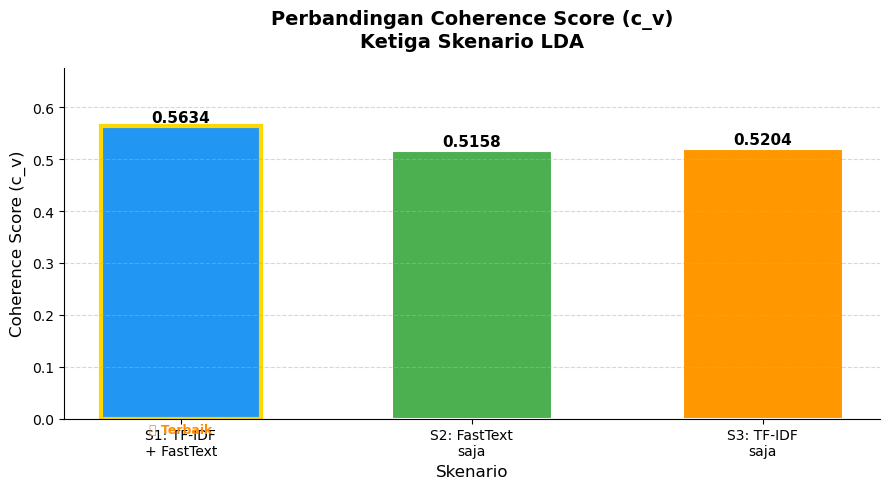

   💾 Disimpan: chart_coherence_comparison.png

📉 2. Bar chart Perplexity...


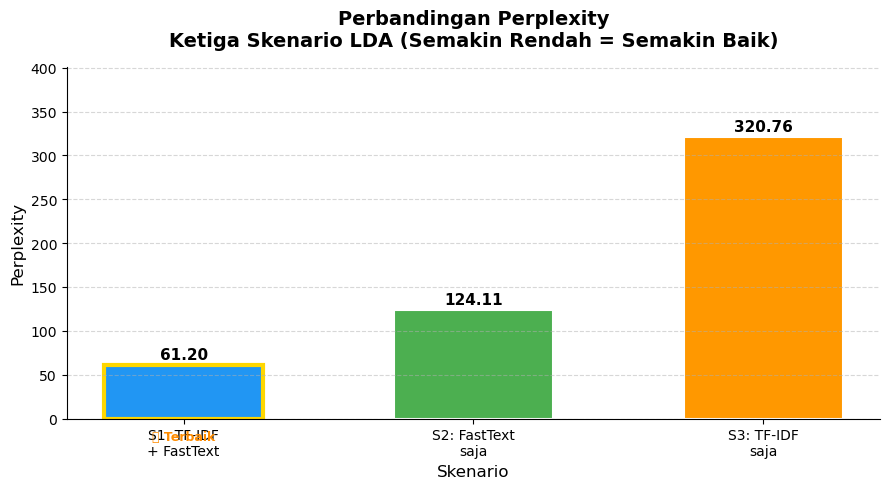

   💾 Disimpan: chart_perplexity_comparison.png

🎯 3. Grouped bar chart Persentase Topik...


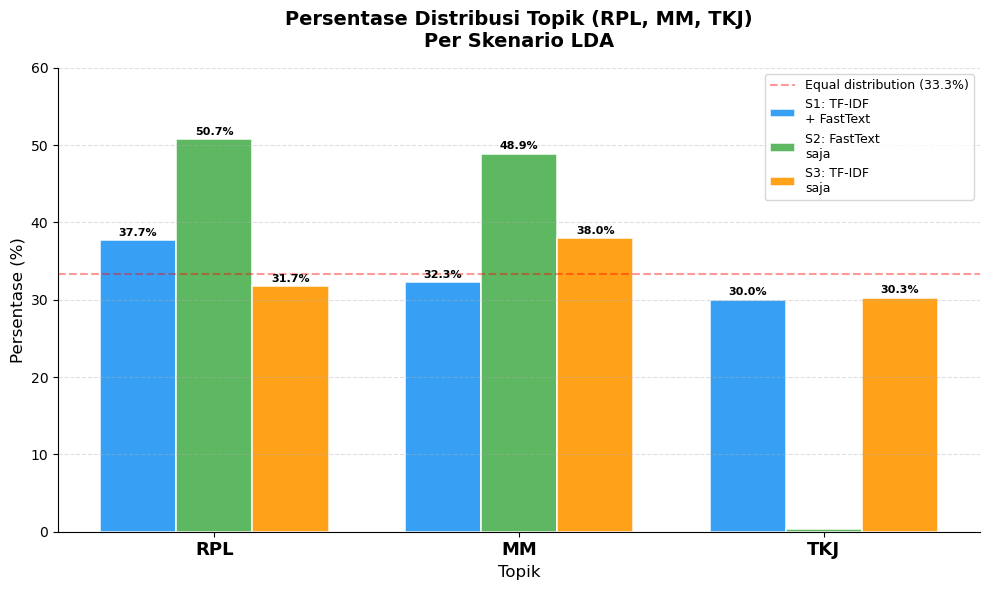

   💾 Disimpan: chart_topic_percentages.png

🍩 4. Donut chart Persentase Topik per Skenario...


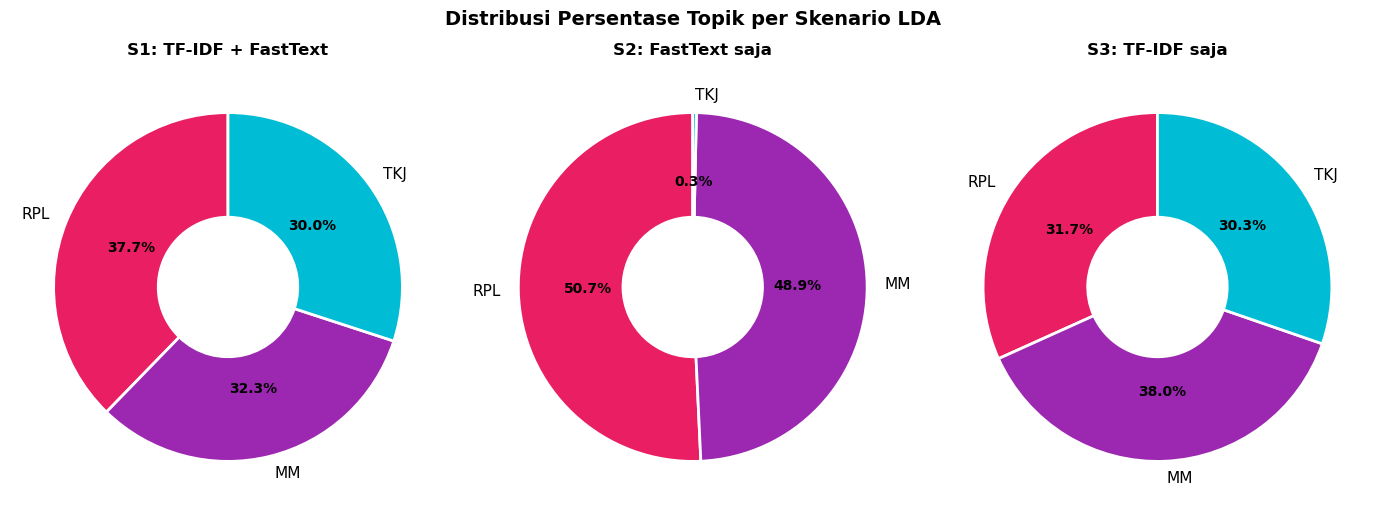

   💾 Disimpan: chart_topic_donut.png


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10: VISUALISASI
# ─────────────────────────────────────────────────────────────────────────────

# Warna tema yang konsisten
COLORS = {
    "s1": "#2196F3",   # Biru - Skenario 1
    "s2": "#4CAF50",   # Hijau - Skenario 2
    "s3": "#FF9800",   # Oranye - Skenario 3
    "RPL": "#E91E63",  # Pink - RPL
    "MM": "#9C27B0",   # Ungu - MM
    "TKJ": "#00BCD4",  # Cyan - TKJ
}

SCENARIO_LABELS_SHORT = [
    "S1: TF-IDF\n+ FastText",
    "S2: FastText\nsaja",
    "S3: TF-IDF\nsaja"
]


def plot_coherence_comparison(coherences, scenario_labels, colors):
    """Bar chart perbandingan Coherence Score ketiga skenario."""
    fig, ax = plt.subplots(figsize=(9, 5))

    bars = ax.bar(
        scenario_labels,
        coherences,
        color=[colors["s1"], colors["s2"], colors["s3"]],
        edgecolor="white",
        linewidth=1.5,
        width=0.55
    )

    # Tambahkan nilai di atas bar
    for bar, val in zip(bars, coherences):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{val:.4f}",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold"
        )

    # Highlight bar terbaik
    best_idx = np.argmax(coherences)
    bars[best_idx].set_edgecolor("gold")
    bars[best_idx].set_linewidth(3)
    ax.text(
        bars[best_idx].get_x() + bars[best_idx].get_width() / 2,
        -0.008,
        "🏆 Terbaik",
        ha="center", va="top",
        fontsize=9, color="darkorange", fontweight="bold"
    )

    ax.set_title(
        "Perbandingan Coherence Score (c_v)\nKetiga Skenario LDA",
        fontsize=14, fontweight="bold", pad=15
    )
    ax.set_ylabel("Coherence Score (c_v)", fontsize=12)
    ax.set_xlabel("Skenario", fontsize=12)
    ax.set_ylim(0, max(coherences) * 1.2)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig("chart_coherence_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   💾 Disimpan: chart_coherence_comparison.png")


def plot_perplexity_comparison(perplexities, scenario_labels, colors):
    """Bar chart perbandingan Perplexity ketiga skenario."""
    fig, ax = plt.subplots(figsize=(9, 5))

    bars = ax.bar(
        scenario_labels,
        perplexities,
        color=[colors["s1"], colors["s2"], colors["s3"]],
        edgecolor="white",
        linewidth=1.5,
        width=0.55
    )

    # Tambahkan nilai di atas bar
    for bar, val in zip(bars, perplexities):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(perplexities) * 0.01,
            f"{val:.2f}",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold"
        )

    # Highlight bar terbaik (perplexity = nilai TERENDAH terbaik)
    best_idx = np.argmin(perplexities)
    bars[best_idx].set_edgecolor("gold")
    bars[best_idx].set_linewidth(3)
    ax.text(
        bars[best_idx].get_x() + bars[best_idx].get_width() / 2,
        -max(perplexities) * 0.04,
        "🏆 Terbaik",
        ha="center", va="top",
        fontsize=9, color="darkorange", fontweight="bold"
    )

    ax.set_title(
        "Perbandingan Perplexity\nKetiga Skenario LDA (Semakin Rendah = Semakin Baik)",
        fontsize=14, fontweight="bold", pad=15
    )
    ax.set_ylabel("Perplexity", fontsize=12)
    ax.set_xlabel("Skenario", fontsize=12)
    ax.set_ylim(0, max(perplexities) * 1.25)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig("chart_perplexity_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   💾 Disimpan: chart_perplexity_comparison.png")


def plot_topic_percentages(pct_s1, pct_s2, pct_s3, scenario_labels, colors):
    """
    Grouped bar chart persentase topik (RPL, MM, TKJ)
    untuk ketiga skenario sekaligus.
    """
    topics = list(TOPIC_LABELS.values())  # ["RPL", "MM", "TKJ"]
    x = np.arange(len(topics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    # Data persentase per skenario
    pct_data = [
        [pct_s1[t] for t in topics],
        [pct_s2[t] for t in topics],
        [pct_s3[t] for t in topics],
    ]

    scenario_colors = [colors["s1"], colors["s2"], colors["s3"]]

    for i, (pct, color, label) in enumerate(zip(pct_data, scenario_colors, scenario_labels)):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, pct, width, label=label, color=color,
                      edgecolor="white", linewidth=1.2, alpha=0.9)

        # Label nilai di atas bar
        for bar, val in zip(bars, pct):
            if val > 1:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f"{val:.1f}%",
                    ha="center", va="bottom",
                    fontsize=8, fontweight="bold"
                )

    ax.set_title(
        "Persentase Distribusi Topik (RPL, MM, TKJ)\nPer Skenario LDA",
        fontsize=14, fontweight="bold", pad=15
    )
    ax.set_ylabel("Persentase (%)", fontsize=12)
    ax.set_xlabel("Topik", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(topics, fontsize=13, fontweight="bold")
    ax.set_ylim(0, 60)
    ax.axhline(y=33.33, color="red", linestyle="--", alpha=0.4, label="Equal distribution (33.3%)")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig("chart_topic_percentages.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   💾 Disimpan: chart_topic_percentages.png")


def plot_topic_percentages_per_scenario(pct_s1, pct_s2, pct_s3, colors):
    """
    Pie chart / donut chart persentase topik per skenario (3 subplot).
    """
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    topics = list(TOPIC_LABELS.values())
    topic_colors = [colors["RPL"], colors["MM"], colors["TKJ"]]

    all_pct = [pct_s1, pct_s2, pct_s3]
    titles = [
        "S1: TF-IDF + FastText",
        "S2: FastText saja",
        "S3: TF-IDF saja"
    ]

    for ax, pct, title in zip(axes, all_pct, titles):
        values = [pct[t] for t in topics]

        wedges, texts, autotexts = ax.pie(
            values,
            labels=topics,
            colors=topic_colors,
            autopct="%1.1f%%",
            startangle=90,
            wedgeprops=dict(width=0.6, edgecolor="white", linewidth=2),  # Donut
            textprops=dict(fontsize=11)
        )

        for autotext in autotexts:
            autotext.set_fontsize(10)
            autotext.set_fontweight("bold")

        ax.set_title(title, fontsize=12, fontweight="bold", pad=10)

    fig.suptitle(
        "Distribusi Persentase Topik per Skenario LDA",
        fontsize=14, fontweight="bold", y=1.02
    )

    plt.tight_layout()
    plt.savefig("chart_topic_donut.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   💾 Disimpan: chart_topic_donut.png")


print("\n" + "="*70)
print("📊 MEMBUAT VISUALISASI...")
print("="*70)

coherences = [coh_s1, coh_s2, coh_s3]
perplexities = [perp_s1, perp_s2, perp_s3]

print("\n📈 1. Bar chart Coherence Score...")
plot_coherence_comparison(coherences, SCENARIO_LABELS_SHORT, COLORS)

print("\n📉 2. Bar chart Perplexity...")
plot_perplexity_comparison(perplexities, SCENARIO_LABELS_SHORT, COLORS)

print("\n🎯 3. Grouped bar chart Persentase Topik...")
plot_topic_percentages(pct_s1, pct_s2, pct_s3, SCENARIO_LABELS_SHORT, COLORS)

print("\n🍩 4. Donut chart Persentase Topik per Skenario...")
plot_topic_percentages_per_scenario(pct_s1, pct_s2, pct_s3, COLORS)

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: BONUS - pyLDAvis INTERAKTIF
# ─────────────────────────────────────────────────────────────────────────────

def visualize_pyldavis(lda_model, corpus, dictionary, scenario_name, filename):
    """
    Membuat visualisasi interaktif menggunakan pyLDAvis.

    pyLDAvis menampilkan:
    - Posisi topik dalam ruang 2D (berdasarkan jarak antar topik)
    - Distribusi kata untuk setiap topik
    - Slider relevance (lambda) untuk menyesuaikan relevansi kata

    Parameters:
        lda_model    : model LDA gensim
        corpus       : corpus gensim
        dictionary   : gensim Dictionary
        scenario_name: nama skenario
        filename     : nama file output HTML
    """
    print(f"\n   🎨 Membuat pyLDAvis untuk {scenario_name}...")

    try:
        # Prepare visualisasi
        vis_data = gensimvis.prepare(
            lda_model,
            corpus,
            dictionary,
            mds="mmds",        # Multidimensional Scaling
            sort_topics=False  # Pertahankan urutan topik asli
        )

        # Simpan sebagai HTML interaktif
        pyLDAvis.save_html(vis_data, filename)
        print(f"   ✅ Visualisasi disimpan: {filename}")
        print(f"      (Buka file HTML di browser untuk interaksi)")

        # Tampilkan inline di Jupyter Notebook
        return vis_data

    except Exception as e:
        print(f"   ⚠️ Error pyLDAvis ({scenario_name}): {e}")
        print(f"      Pastikan corpus memiliki distribusi topik yang valid.")
        return None


print("\n" + "="*70)
print("🎨 BONUS: VISUALISASI pyLDAvis INTERAKTIF")
print("="*70)

# pyLDAvis untuk ketiga skenario
vis_s1 = visualize_pyldavis(lda_s1, corpus_scenario1, dictionary,
                              "Skenario 1: TF-IDF + FastText",
                              "pyldavis_skenario1_tfidf_fasttext.html")

vis_s2 = visualize_pyldavis(lda_s2, corpus_scenario2, dictionary,
                              "Skenario 2: FastText saja",
                              "pyldavis_skenario2_fasttext.html")

vis_s3 = visualize_pyldavis(lda_s3, corpus_scenario3, dictionary,
                              "Skenario 3: TF-IDF saja (Baseline)",
                              "pyldavis_skenario3_tfidf.html")

# Tampilkan inline di Jupyter (tampilkan skenario terbaik)
print("\n💡 Menampilkan pyLDAvis inline (Skenario dengan Coherence Terbaik)...")

best_coherence_skenario = np.argmax(coherences)  # 0=S1, 1=S2, 2=S3
vis_list = [vis_s1, vis_s2, vis_s3]
best_vis = vis_list[best_coherence_skenario]

if best_vis is not None:
    pyLDAvis.enable_notebook()
    display(best_vis)  # Tampilkan inline di Jupyter Notebook


🎨 BONUS: VISUALISASI pyLDAvis INTERAKTIF

   🎨 Membuat pyLDAvis untuk Skenario 1: TF-IDF + FastText...
   ✅ Visualisasi disimpan: pyldavis_skenario1_tfidf_fasttext.html
      (Buka file HTML di browser untuk interaksi)

   🎨 Membuat pyLDAvis untuk Skenario 2: FastText saja...
   ✅ Visualisasi disimpan: pyldavis_skenario2_fasttext.html
      (Buka file HTML di browser untuk interaksi)

   🎨 Membuat pyLDAvis untuk Skenario 3: TF-IDF saja (Baseline)...
   ✅ Visualisasi disimpan: pyldavis_skenario3_tfidf.html
      (Buka file HTML di browser untuk interaksi)

💡 Menampilkan pyLDAvis inline (Skenario dengan Coherence Terbaik)...


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.045630  0.105863       1        1  34.180366
1      0.092216 -0.108443       2        1  38.659464
2     -0.137846  0.002581       3        1  27.160170, topic_info=         Term       Freq      Total Category  logprob  loglift
2        ajar  43.000000  43.000000  Default  30.0000  30.0000
313    jaring  22.000000  22.000000  Default  29.0000  29.0000
199   dokumen  18.000000  18.000000  Default  28.0000  28.0000
142     siswa  23.000000  23.000000  Default  27.0000  27.0000
480    server  11.000000  11.000000  Default  26.0000  26.0000
..        ...        ...        ...      ...      ...      ...
350       unj   1.749713   2.949436   Topic3  -5.3375   0.7813
72   komputer   1.994913   4.587590   Topic3  -5.2064   0.4707
96      media   2.588217  14.262686   Topic3  -4.9460  -0.4033
248    negeri   2.018020   5.869382   Topic3  -5.1948   0.2358
40      fitur   1.850826   5.090844   Topic3  -5.2813   0.2916

[155 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
179       1  0.954458     admin
1         1  0.200883      ahli
1         2  0.602649      ahli
2         1  0.068362      ajar
2         2  0.934276      ajar
...     ...       ...       ...
174       3  0.622434     usaha
352       2  0.871400  variabel
295       1  0.142770       web
295       3  0.713850       web
516       1  0.762976      word

[178 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3])

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12: RINGKASAN AKHIR
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("✅ RINGKASAN HASIL TOPIC MODELING LDA - JURNAL PINTER")
print("="*70)

print(f"""
📌 PARAMETER:
   - Jumlah dokumen    : {len(raw_documents)} artikel
   - Jumlah topik      : {NUM_TOPICS} (RPL, MM, TKJ)
   - FastText dim      : {FASTTEXT_VECTOR_SIZE}
   - LDA passes        : {LDA_PASSES}

📊 HASIL PERBANDINGAN:
   ┌────────────────────────────────────┬──────────────┬────────────────┐
   │ Skenario                           │ Coherence ↑  │ Perplexity ↓   │
   ├────────────────────────────────────┼──────────────┼────────────────┤
   │ S1: TF-IDF + FastText (Kombinasi)  │ {coh_s1:.4f}      │ {perp_s1:.4f}         │
   │ S2: FastText saja                  │ {coh_s2:.4f}      │ {perp_s2:.4f}         │
   │ S3: TF-IDF saja (Baseline)         │ {coh_s3:.4f}      │ {perp_s3:.4f}         │
   └────────────────────────────────────┴──────────────┴────────────────┘

📈 PERSENTASE TOPIK (Skenario 1: TF-IDF + FastText):
   - RPL : {pct_s1['RPL']:.2f}%
   - MM  : {pct_s1['MM']:.2f}%
   - TKJ : {pct_s1['TKJ']:.2f}%

🏆 MODEL TERBAIK:
   - Berdasarkan Coherence : Skenario {np.argmax(coherences)+1}
   - Berdasarkan Perplexity: Skenario {np.argmin(perplexities)+1}

📁 FILE OUTPUT YANG DIHASILKAN:
   - chart_coherence_comparison.png
   - chart_perplexity_comparison.png
   - chart_topic_percentages.png
   - chart_topic_donut.png
   - pyldavis_skenario1_tfidf_fasttext.html
   - pyldavis_skenario2_fasttext.html
   - pyldavis_skenario3_tfidf.html
""")

print("=" * 70)
print("🎉 SELESAI! Semua analisis berhasil dijalankan.")
print("=" * 70)


✅ RINGKASAN HASIL TOPIC MODELING LDA - JURNAL PINTER

📌 PARAMETER:
   - Jumlah dokumen    : 10 artikel
   - Jumlah topik      : 3 (RPL, MM, TKJ)
   - FastText dim      : 300
   - LDA passes        : 50

📊 HASIL PERBANDINGAN:
   ┌────────────────────────────────────┬──────────────┬────────────────┐
   │ Skenario                           │ Coherence ↑  │ Perplexity ↓   │
   ├────────────────────────────────────┼──────────────┼────────────────┤
   │ S1: TF-IDF + FastText (Kombinasi)  │ 0.5634      │ 61.1989         │
   │ S2: FastText saja                  │ 0.5158      │ 124.1063         │
   │ S3: TF-IDF saja (Baseline)         │ 0.5204      │ 320.7603         │
   └────────────────────────────────────┴──────────────┴────────────────┘

📈 PERSENTASE TOPIK (Skenario 1: TF-IDF + FastText):
   - RPL : 37.72%
   - MM  : 32.26%
   - TKJ : 30.02%

🏆 MODEL TERBAIK:
   - Berdasarkan Coherence : Skenario 1
   - Berdasarkan Perplexity: Skenario 1

📁 FILE OUTPUT YANG DIHASILKAN:
   - chart_cohere